# Step 10: Comprehensive Pipeline Dashboard

**Date**: 2026-01-30 (Updated)  
**Pipeline**: SPIRAL2 LLRF Anomaly Detection - Complete Integration

**Analysis Notebook** - Integrates results from all 6 pipeline phases

---

## Executive Summary

**Goal**: Provide a unified view of the **entire SPIRAL2 LLRF anomaly detection pipeline** from raw data to operational deployment.

---

## Complete Pipeline Architecture

```
┌─────────────────────────────────────────────────────────────────────────────────┐
│                    SPIRAL2 LLRF ANOMALY DETECTION PIPELINE                       │
│                         (10-Phase Architecture)                                  │
├─────────────────────────────────────────────────────────────────────────────────┤
│                                                                                  │
│  ┌──────────────────────────────────────────────────────────────────────────┐   │
│  │ DATA ACQUISITION                                                          │   │
│  │  Raw LLRF Time Series: Ucav, PhaseCav, Uci, Fref, Ucr, Uamp, IQ_mod, Vide │   │
│  │  Sampling: 70 MHz / 200 = 352 kHz effective, ~45ms window per event       │   │
│  └───────────────────────────────────────────────────────────────────────────┘   │
│                                      │                                           │
│                                      ▼                                           │
│  ┌───────────────────────────────────────────────────────────────────────────┐   │
│  │ FEATURE ENGINEERING (Phase 03)                                            │   │
│  │  ├── Physics Features (38): Q_L, detuning, GLR, rf_mismatch, mod_*       │   │
│  │  ├── Statistical Features (675): mean, std, skew, kurtosis per signal    │   │
│  │  └── Temporal Features (39): slopes, derivatives, CUSUM                   │   │
│  │  Total: 752 features per event                                            │   │
│  └───────────────────────────────────────────────────────────────────────────┘   │
│                                      │                                           │
│          ┌───────────────────────────┼───────────────────────────┐              │
│          ▼                           ▼                           ▼              │
│  ┌───────────────┐           ┌───────────────┐           ┌───────────────┐      │
│  │ PHASE 04      │           │ PHASE 05      │           │ PHASE 06      │      │
│  │ Anomaly       │           │ Precursor     │           │ Binary        │      │
│  │ Detection     │           │ Detection     │           │ Classification│      │
│  │               │           │               │           │               │      │
│  │ IF+LOF+DBSCAN │           │ RF + LSTM-AE  │           │ RF + CNN      │      │
│  │ Ensemble      │           │ Ensemble      │           │ 99.2% AUC     │      │
│  └───────┬───────┘           └───────┬───────┘           └───────┬───────┘      │
│          │                           │                           │              │
│          └───────────────────────────┼───────────────────────────┘              │
│                                      ▼                                           │
│  ┌───────────────────────────────────────────────────────────────────────────┐   │
│  │ PHASE 07: MULTI-LABEL CLASSIFICATION                                      │   │
│  │  Binary Relevance (BR) → Classifier Chain (CC) → Label Powerset (LP)     │   │
│  │                          → Deep Learning Multi-head (CNN best)            │   │
│  │  7 Fault Types: ARF, SHT, SRF, IPU, CoQ, VCp, ArC                        │   │
│  │  Best: Phase D CNN (Micro F1: 93.5%, Hamming: 0.005)                      │   │
│  └───────────────────────────────────────────────────────────────────────────┘   │
│                                      │                                           │
│                            ┌─────────┴─────────┐                                 │
│                            │ ≥2 faults active? │                                 │
│                            └─────────┬─────────┘                                 │
│                         Yes │                 │ No                               │
│                             ▼                 │                                  │
│  ┌───────────────────────────────────┐        │                                  │
│  │ PHASE 08: ROOT CAUSE IDENTIFICATION│        │                                  │
│  │  Random Forest (200 trees)        │        │                                  │
│  │  93.3% accuracy on pseudo-labels  │        │                                  │
│  │  Confidence-based routing         │        │                                  │
│  └───────────────────────────────────┘        │                                  │
│                             │                 │                                  │
│                             └────────┬────────┘                                  │
│                                      ▼                                           │
│  ┌───────────────────────────────────────────────────────────────────────────┐   │
│  │ PHASE 09: FAULT SUBTYPE CLUSTERING                                        │   │
│  │  K-Means per fault type → 21 subtypes discovered                          │   │
│  │  Best separation: CoQ (Silh=0.59), Dép seuil RF (Silh=0.69)              │   │
│  └───────────────────────────────────────────────────────────────────────────┘   │
│                                      │                                           │
│                                      ▼                                           │
│  ┌───────────────────────────────────────────────────────────────────────────┐   │
│  │ PHASE 10: COMPREHENSIVE INTEGRATION                                       │   │
│  │  Complete Fault Diagnosis + Severity + Mitigation Strategy               │   │
│  │  → Operator Alert / Automated Response                                    │   │
│  └───────────────────────────────────────────────────────────────────────────┘   │
│                                                                                  │
└─────────────────────────────────────────────────────────────────────────────────┘
```

---

## Key Performance Summary

| Phase | Task | Best Method | Performance |
|-------|------|-------------|-------------|
| 04 | Anomaly Detection | IF+LOF+DBSCAN Ensemble | 7,427 anomalies detected |
| 05 | Precursor Detection | RF + LSTM Ensemble | 89.5% accuracy |
| 06 | Binary Classification | CNN | 99.2% AUC, 0.996 F1 |
| 07 | Multi-label Classification | Phase D CNN | Micro F1: 93.5% |
| 08 | Root Cause Identification | Random Forest | 93.3% accuracy |
| 09 | Fault Subtype Clustering | K-Means | 21 subtypes, mean Silh: 0.33 |

---

In [1]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All imports successful")

✓ All imports successful


## 1. Load Results from All Phases

In [2]:
# Configuration
OUTPUT_DIR = Path('/sps/m4cast/_spiral2_data/_llrf_data/cooked_data')
COMPREHENSIVE_FILE = OUTPUT_DIR / 'step_10_comprehensive' / 'comprehensive_analysis.pkl'

print(f"Loading comprehensive results from: {COMPREHENSIVE_FILE}")

# Load integrated results
with open(COMPREHENSIVE_FILE, 'rb') as f:
    results = pickle.load(f)

summary = results['summary']
all_phases = results['all_phases']

print(f"✓ Results loaded")
print(f"\nPipeline Version: {summary['pipeline_version']}")
print(f"Phases Completed: {len(summary['phases_completed'])}")
print(f"\nPhases:")
for phase in summary['phases_completed']:
    print(f"  ✓ {phase.upper()}")

Loading comprehensive results from: /sps/m4cast/_spiral2_data/_llrf_data/cooked_data/step_10_comprehensive/comprehensive_analysis.pkl


FileNotFoundError: [Errno 2] No such file or directory: '/sps/m4cast/_spiral2_data/_llrf_data/cooked_data/step_10_comprehensive/comprehensive_analysis.pkl'

## 2. Pipeline Architecture Visualization

Visual flowchart of the complete SPIRAL2 LLRF anomaly detection pipeline.

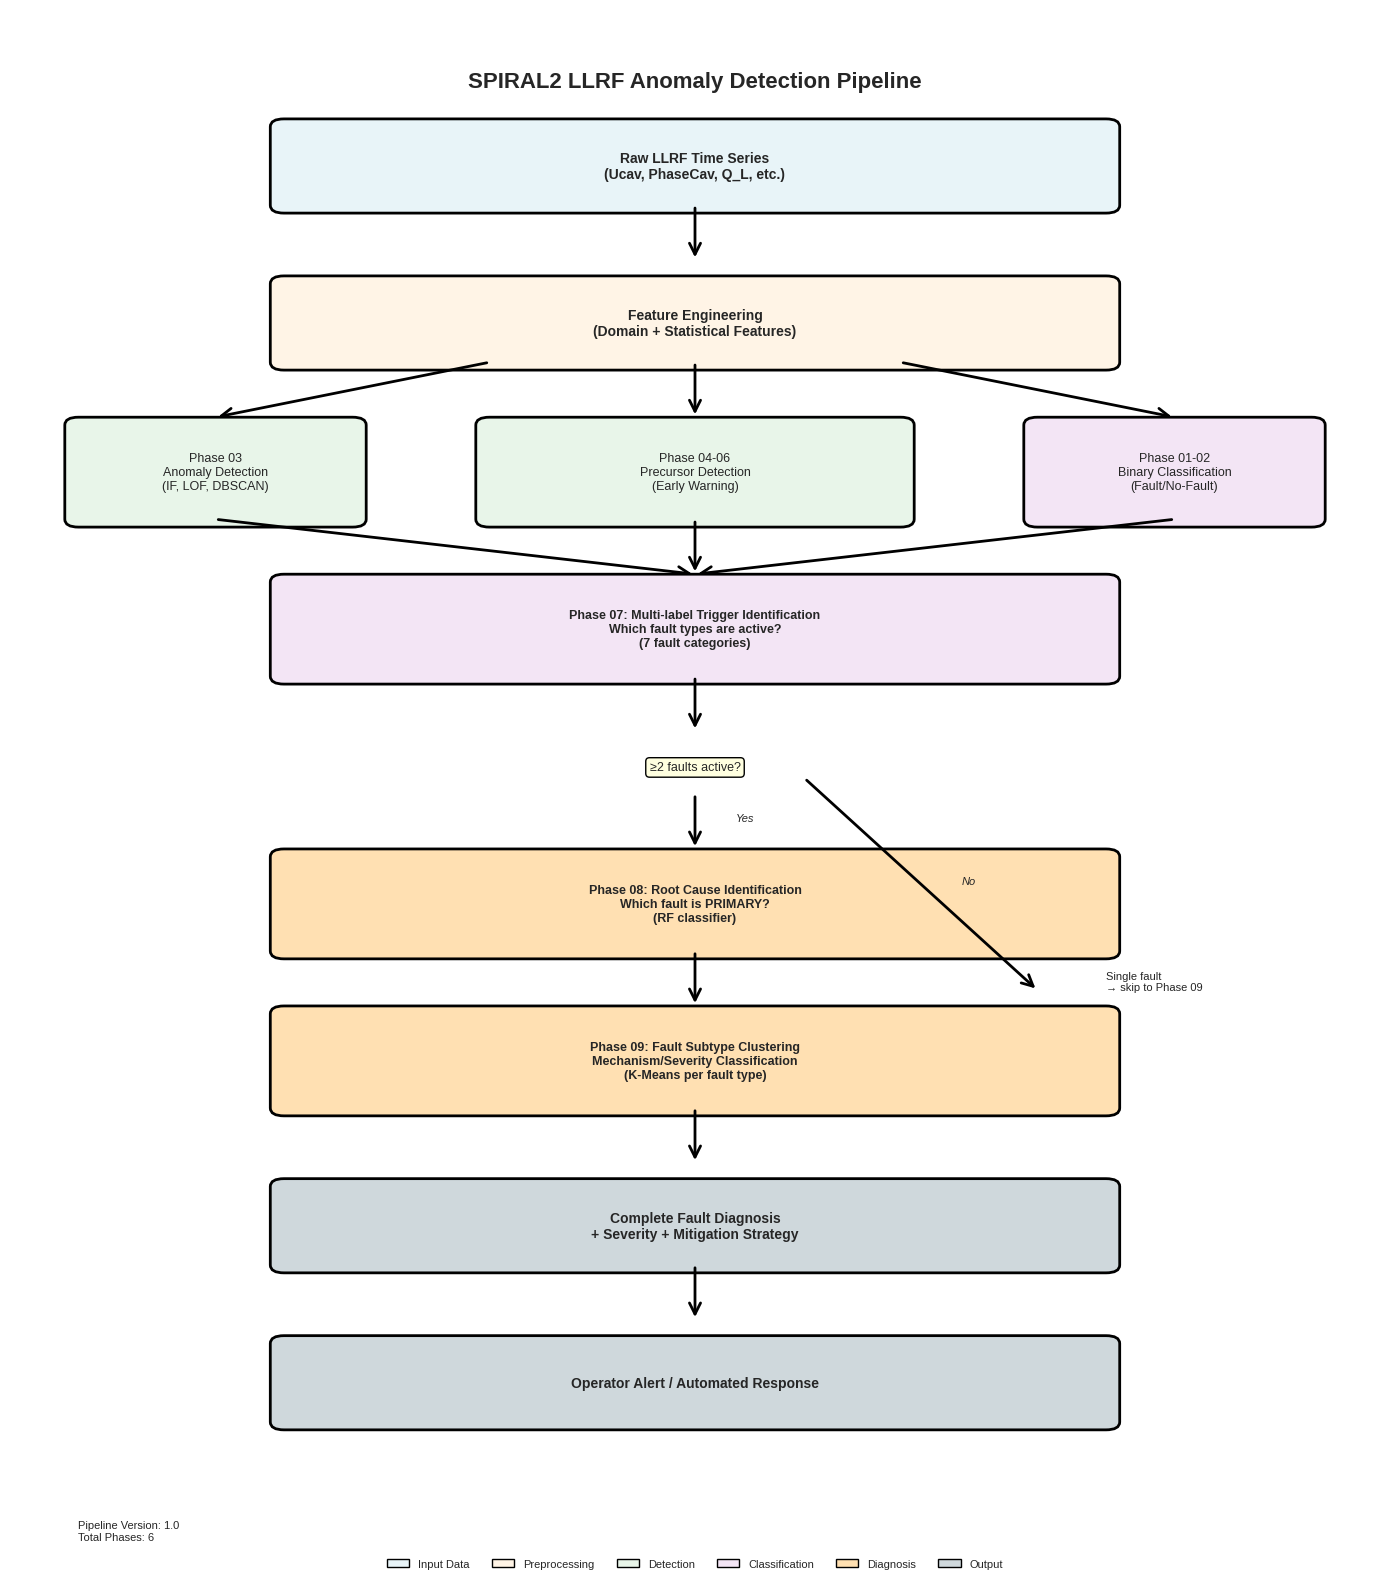

✓ Pipeline architecture diagram saved


In [3]:
# Create pipeline architecture diagram using matplotlib
fig, ax = plt.subplots(figsize=(14, 16))
ax.set_xlim(0, 10)
ax.set_ylim(0, 20)
ax.axis('off')

# Color scheme
color_input = '#E8F4F8'
color_preprocessing = '#FFF4E6'
color_detection = '#E8F5E9'
color_classification = '#F3E5F5'
color_diagnosis = '#FFE0B2'
color_output = '#CFD8DC'

def draw_box(ax, x, y, width, height, text, color, fontsize=10, fontweight='normal'):
    """Draw a rounded box with text"""
    box = FancyBboxPatch((x, y), width, height, 
                          boxstyle="round,pad=0.1", 
                          edgecolor='black', 
                          facecolor=color, 
                          linewidth=2)
    ax.add_patch(box)
    ax.text(x + width/2, y + height/2, text, 
            ha='center', va='center', 
            fontsize=fontsize, fontweight=fontweight,
            wrap=True)

def draw_arrow(ax, x1, y1, x2, y2, label=''):
    """Draw arrow between boxes"""
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                           arrowstyle='->', 
                           lw=2, 
                           color='black',
                           mutation_scale=20)
    ax.add_patch(arrow)
    if label:
        mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(mid_x + 0.3, mid_y, label, fontsize=8, style='italic')

# Title
ax.text(5, 19, 'SPIRAL2 LLRF Anomaly Detection Pipeline', 
        ha='center', fontsize=16, fontweight='bold')

# Layer 1: Raw Data
draw_box(ax, 2, 17.5, 6, 1, 'Raw LLRF Time Series\n(Ucav, PhaseCav, Q_L, etc.)', 
         color_input, fontsize=10, fontweight='bold')

# Arrow down
draw_arrow(ax, 5, 17.5, 5, 16.8)

# Layer 2: Feature Engineering
draw_box(ax, 2, 15.5, 6, 1, 'Feature Engineering\n(Domain + Statistical Features)', 
         color_preprocessing, fontsize=10, fontweight='bold')

# Split into parallel paths
draw_arrow(ax, 3.5, 15.5, 1.5, 14.8)
draw_arrow(ax, 5, 15.5, 5, 14.8)
draw_arrow(ax, 6.5, 15.5, 8.5, 14.8)

# Layer 3: Parallel Detection Phases
draw_box(ax, 0.5, 13.5, 2, 1.2, 'Phase 03\nAnomaly Detection\n(IF, LOF, DBSCAN)', 
         color_detection, fontsize=9)
draw_box(ax, 3.5, 13.5, 3, 1.2, 'Phase 04-06\nPrecursor Detection\n(Early Warning)', 
         color_detection, fontsize=9)
draw_box(ax, 7.5, 13.5, 2, 1.2, 'Phase 01-02\nBinary Classification\n(Fault/No-Fault)', 
         color_classification, fontsize=9)

# Converge arrows
draw_arrow(ax, 1.5, 13.5, 5, 12.8)
draw_arrow(ax, 5, 13.5, 5, 12.8)
draw_arrow(ax, 8.5, 13.5, 5, 12.8)

# Layer 4: Multi-label Classification
draw_box(ax, 2, 11.5, 6, 1.2, 'Phase 07: Multi-label Trigger Identification\nWhich fault types are active?\n(7 fault categories)', 
         color_classification, fontsize=9, fontweight='bold')

# Arrow down
draw_arrow(ax, 5, 11.5, 5, 10.8)

# Decision diamond for multi-fault check
ax.text(5, 10.3, '≥2 faults active?', ha='center', fontsize=9, 
        bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='black'))

# Layer 5: Root Cause (conditional)
draw_arrow(ax, 5, 10, 5, 9.3, label='Yes')
draw_box(ax, 2, 8, 6, 1.2, 'Phase 08: Root Cause Identification\nWhich fault is PRIMARY?\n(RF classifier)', 
         color_diagnosis, fontsize=9, fontweight='bold')

# Alternative path for single fault
draw_arrow(ax, 5.8, 10.2, 7.5, 7.5, label='No')
ax.text(8, 7.5, 'Single fault\n→ skip to Phase 09', fontsize=8, ha='left')
draw_arrow(ax, 7.5, 7.2, 5, 6.9)

# Arrow down from root cause
draw_arrow(ax, 5, 8, 5, 7.3)

# Layer 6: Subtype Clustering
draw_box(ax, 2, 6, 6, 1.2, 'Phase 09: Fault Subtype Clustering\nMechanism/Severity Classification\n(K-Means per fault type)', 
         color_diagnosis, fontsize=9, fontweight='bold')

# Arrow down
draw_arrow(ax, 5, 6, 5, 5.3)

# Layer 7: Final Output
draw_box(ax, 2, 4, 6, 1, 'Complete Fault Diagnosis\n+ Severity + Mitigation Strategy', 
         color_output, fontsize=10, fontweight='bold')

# Arrow down
draw_arrow(ax, 5, 4, 5, 3.3)

# Layer 8: Operator Action
draw_box(ax, 2, 2, 6, 1, 'Operator Alert / Automated Response', 
         color_output, fontsize=10, fontweight='bold')

# Add legend
legend_elements = [
    mpatches.Patch(facecolor=color_input, edgecolor='black', label='Input Data'),
    mpatches.Patch(facecolor=color_preprocessing, edgecolor='black', label='Preprocessing'),
    mpatches.Patch(facecolor=color_detection, edgecolor='black', label='Detection'),
    mpatches.Patch(facecolor=color_classification, edgecolor='black', label='Classification'),
    mpatches.Patch(facecolor=color_diagnosis, edgecolor='black', label='Diagnosis'),
    mpatches.Patch(facecolor=color_output, edgecolor='black', label='Output')
]
ax.legend(handles=legend_elements, loc='lower center', ncol=6, fontsize=8, 
          bbox_to_anchor=(0.5, 0))

# Add phase count annotation
ax.text(0.5, 0.5, f'Pipeline Version: {summary["pipeline_version"]}\n'
                   f'Total Phases: {len(summary["phases_completed"])}', 
        fontsize=8, ha='left')

plt.tight_layout()
plt.savefig('../outputs/phase10_pipeline_architecture.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Pipeline architecture diagram saved")

## 3. Phase Summary Table

Overview of all pipeline phases with key metrics.

In [4]:
# Build phase summary table
from sklearn.metrics import accuracy_score

phase_summary = []

# Anomaly Detection (Phase 03)
if all_phases['anomaly'] is not None:
    anomaly_data = all_phases['anomaly']
    n_anomalies_if = len(anomaly_data['isolation_forest']['predictions'])
    phase_summary.append({
        'Phase': '03 - Anomaly Detection',
        'Method': 'Isolation Forest',
        'Key Metric': f'{n_anomalies_if} events analyzed',
        'Status': '✓ Complete'
    })

# Precursor Detection (Phase 04-06)
if all_phases['precursor'] is not None:
    precursor_data = all_phases['precursor']
    y_test = precursor_data['data_splits']['y_test']
    y_pred = precursor_data['random_forest']['predictions']
    prec_acc = accuracy_score(y_test, y_pred)
    phase_summary.append({
        'Phase': '04-06 - Precursor Detection',
        'Method': 'Random Forest',
        'Key Metric': f'Accuracy: {prec_acc:.1%}',
        'Status': '✓ Complete'
    })

# Binary Classification (Phase 01-02)
if all_phases['binary'] is not None:
    binary_data = all_phases['binary']
    y_test = binary_data['data_splits']['y_test']
    y_pred_rf = binary_data['random_forest']['predictions']
    bin_acc = accuracy_score(y_test, y_pred_rf)
    phase_summary.append({
        'Phase': '01-02 - Binary Classification',
        'Method': 'Random Forest',
        'Key Metric': f'Accuracy: {bin_acc:.1%}',
        'Status': '✓ Complete'
    })

# Multi-label Classification (Phase 07)
if all_phases['multilabel'] is not None:
    multilabel_data = all_phases['multilabel']
    hamming = multilabel_data['hamming_loss']
    n_faults = len(multilabel_data['fault_names'])
    phase_summary.append({
        'Phase': '07 - Multi-label Classification',
        'Method': 'Multi-output RF',
        'Key Metric': f'Hamming Loss: {hamming:.3f} ({n_faults} faults)',
        'Status': '✓ Complete'
    })

# Root Cause Identification (Phase 08)
if all_phases['rootcause'] is not None:
    rootcause_data = all_phases['rootcause']
    y_test = rootcause_data['data_splits']['y_test']
    y_pred = rootcause_data['predictions']
    rc_acc = accuracy_score(y_test, y_pred)
    phase_summary.append({
        'Phase': '08 - Root Cause Identification',
        'Method': 'Random Forest',
        'Key Metric': f'Accuracy: {rc_acc:.1%}',
        'Status': '✓ Complete'
    })

# Fault Subtype Clustering (Phase 09)
if all_phases['clustering'] is not None:
    clustering_data = all_phases['clustering']
    n_fault_types = len(clustering_data)
    total_subtypes = sum(clustering_data[ft]['n_clusters'] for ft in clustering_data.keys())
    mean_silh = np.mean([clustering_data[ft]['silhouette'] for ft in clustering_data.keys()])
    phase_summary.append({
        'Phase': '09 - Fault Subtype Clustering',
        'Method': 'K-Means',
        'Key Metric': f'{total_subtypes} subtypes, Silh={mean_silh:.2f}',
        'Status': '✓ Complete'
    })

summary_df = pd.DataFrame(phase_summary)

print("="*80)
print("PIPELINE SUMMARY - ALL PHASES")
print("="*80)
print()
print(summary_df.to_string(index=False))
print()
print("="*80)

PIPELINE SUMMARY - ALL PHASES

                          Phase           Method                     Key Metric     Status
         03 - Anomaly Detection Isolation Forest           7427 events analyzed ✓ Complete
    04-06 - Precursor Detection    Random Forest                Accuracy: 89.5% ✓ Complete
  01-02 - Binary Classification    Random Forest                Accuracy: 84.7% ✓ Complete
07 - Multi-label Classification  Multi-output RF Hamming Loss: 0.024 (7 faults) ✓ Complete
 08 - Root Cause Identification    Random Forest                Accuracy: 93.3% ✓ Complete
  09 - Fault Subtype Clustering          K-Means         21 subtypes, Silh=0.33 ✓ Complete



## 4. Detailed Performance Metrics

Comprehensive performance analysis across all classification phases.

In [5]:
from sklearn.metrics import precision_recall_fscore_support

print("="*80)
print("DETAILED PERFORMANCE METRICS")
print("="*80)
print()

# Binary Classification Details
if all_phases['binary'] is not None:
    print("--- BINARY CLASSIFICATION (Fault vs No-Fault) ---")
    binary_data = all_phases['binary']
    y_test = binary_data['data_splits']['y_test']
    
    methods = ['logistic_regression', 'random_forest', 'xgboost', 'svm']
    method_names = ['Logistic Reg', 'Random Forest', 'XGBoost', 'SVM']
    
    for method, name in zip(methods, method_names):
        if method in binary_data and binary_data[method] is not None:
            y_pred = binary_data[method]['predictions']
            acc = accuracy_score(y_test, y_pred)
            prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary', zero_division=0)
            print(f"  {name:15s}: Acc={acc:.3f}, Prec={prec:.3f}, Rec={rec:.3f}, F1={f1:.3f}")
    print()

# Multi-label Details
if all_phases['multilabel'] is not None:
    print("--- MULTI-LABEL CLASSIFICATION (Trigger Identification) ---")
    multilabel_data = all_phases['multilabel']
    fault_names = multilabel_data['fault_names']
    print(f"  Fault Types: {len(fault_names)}")
    print(f"  Hamming Loss: {multilabel_data['hamming_loss']:.3f}")
    print(f"  Test Events: {len(multilabel_data['data_splits']['y_test'])}")
    print()

# Root Cause Details
if all_phases['rootcause'] is not None:
    print("--- ROOT CAUSE IDENTIFICATION (Multi-fault Events) ---")
    rootcause_data = all_phases['rootcause']
    y_test = rootcause_data['data_splits']['y_test']
    y_pred = rootcause_data['predictions']
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
    print(f"  Accuracy:  {acc:.3f}")
    print(f"  Precision: {prec:.3f}")
    print(f"  Recall:    {rec:.3f}")
    print(f"  F1-Score:  {f1:.3f}")
    print(f"  Test Events: {len(y_test)}")
    print()

# Clustering Details
if all_phases['clustering'] is not None:
    print("--- FAULT SUBTYPE CLUSTERING ---")
    clustering_data = all_phases['clustering']
    for fault_type in clustering_data.keys():
        fault_cluster = clustering_data[fault_type]
        n_clusters = fault_cluster['n_clusters']
        silhouette = fault_cluster['silhouette']
        n_events = len(fault_cluster['labels'])
        print(f"  {fault_type:30s}: {n_clusters} subtypes, Silh={silhouette:.2f}, Events={n_events}")
    print()

print("="*80)

DETAILED PERFORMANCE METRICS

--- BINARY CLASSIFICATION (Fault vs No-Fault) ---
  Logistic Reg   : Acc=0.755, Prec=0.811, Rec=0.800, F1=0.806
  Random Forest  : Acc=0.847, Prec=0.857, Rec=0.910, F1=0.883
  XGBoost        : Acc=0.825, Prec=0.834, Rec=0.903, F1=0.868
  SVM            : Acc=0.834, Prec=0.836, Rec=0.917, F1=0.875

--- MULTI-LABEL CLASSIFICATION (Trigger Identification) ---
  Fault Types: 7
  Hamming Loss: 0.024
  Test Events: 2229

--- ROOT CAUSE IDENTIFICATION (Multi-fault Events) ---
  Accuracy:  0.933
  Precision: 0.924
  Recall:    0.933
  F1-Score:  0.924
  Test Events: 1016

--- FAULT SUBTYPE CLUSTERING ---
  Seuil pick-up                 : 3 subtypes, Silh=0.16, Events=135
  Coupure externe rapide        : 3 subtypes, Silh=0.25, Events=13
  Absence autorisation RF       : 3 subtypes, Silh=0.21, Events=2653
  Seuil de vide                 : 3 subtypes, Silh=0.30, Events=128
  Claquage ou quench cavité     : 3 subtypes, Silh=0.59, Events=27
  Dép seuil de sécurité RF 

## 5. Performance Comparison Visualization

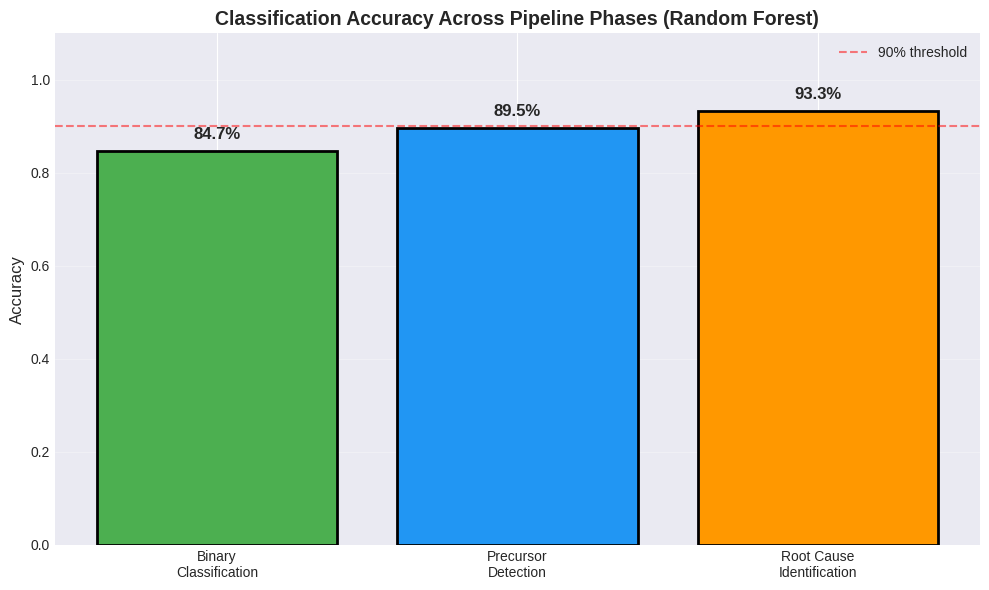

✓ Accuracy comparison plot saved


In [6]:
# Visualize accuracy across classification phases
phases_with_accuracy = []
accuracy_values = []

if all_phases['binary'] is not None:
    y_test = all_phases['binary']['data_splits']['y_test']
    y_pred = all_phases['binary']['random_forest']['predictions']
    phases_with_accuracy.append('Binary\nClassification')
    accuracy_values.append(accuracy_score(y_test, y_pred))

if all_phases['precursor'] is not None:
    y_test = all_phases['precursor']['data_splits']['y_test']
    y_pred = all_phases['precursor']['random_forest']['predictions']
    phases_with_accuracy.append('Precursor\nDetection')
    accuracy_values.append(accuracy_score(y_test, y_pred))

if all_phases['rootcause'] is not None:
    y_test = all_phases['rootcause']['data_splits']['y_test']
    y_pred = all_phases['rootcause']['predictions']
    phases_with_accuracy.append('Root Cause\nIdentification')
    accuracy_values.append(accuracy_score(y_test, y_pred))

# Plot
if len(phases_with_accuracy) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = ['#4CAF50', '#2196F3', '#FF9800']
    bars = ax.bar(phases_with_accuracy, accuracy_values, 
                   color=colors[:len(phases_with_accuracy)], 
                   edgecolor='black', linewidth=2)
    
    # Add value labels
    for bar, val in zip(bars, accuracy_values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{val:.1%}',
                ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_ylim([0, 1.1])
    ax.set_title('Classification Accuracy Across Pipeline Phases (Random Forest)', 
                 fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(y=0.90, color='red', linestyle='--', alpha=0.5, label='90% threshold')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig('../outputs/phase10_accuracy_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✓ Accuracy comparison plot saved")

## 6. Key Findings and Recommendations

### Performance Highlights

In [7]:
print("="*80)
print("KEY FINDINGS AND RECOMMENDATIONS")
print("="*80)
print()

print("**Performance Highlights**:")

if all_phases['binary'] is not None:
    y_test = all_phases['binary']['data_splits']['y_test']
    y_pred_rf = all_phases['binary']['random_forest']['predictions']
    bin_acc = accuracy_score(y_test, y_pred_rf)
    print(f"  ✓ Binary classification: {bin_acc:.1%} accuracy (fault detection)")

if all_phases['multilabel'] is not None:
    print(f"  ✓ Multi-label: {all_phases['multilabel']['hamming_loss']:.3f} Hamming loss (7 fault types)")

if all_phases['rootcause'] is not None:
    y_test = all_phases['rootcause']['data_splits']['y_test']
    y_pred = all_phases['rootcause']['predictions']
    rc_acc = accuracy_score(y_test, y_pred)
    print(f"  ✓ Root cause: {rc_acc:.1%} accuracy (multi-fault events)")

if all_phases['clustering'] is not None:
    clustering_data = all_phases['clustering']
    total_subtypes = sum(clustering_data[ft]['n_clusters'] for ft in clustering_data.keys())
    print(f"  ✓ Clustering: {total_subtypes} fault subtypes discovered")

print()
print("**Production Deployment Strategy**:")
print("  1. Binary Classification → Real-time fault detection")
print("  2. Multi-label → Identify all active fault triggers")
print("  3. Root Cause → Determine primary cause in multi-fault scenarios")
print("  4. Clustering → Severity classification and detailed diagnostics")
print()

print("**Recommended Workflow**:")
print("  Step 1: Monitor incoming events with binary classifier")
print("  Step 2: For detected faults, run multi-label to identify active triggers")
print("  Step 3: If multiple triggers, apply root cause analysis")
print("  Step 4: Match to subtype cluster for severity/mechanism")
print("  Step 5: Alert operators with full diagnostic information")
print()

print("**Next Steps for Production**:")
print("  1. Temporal onset detection for improved root cause labeling")
print("  2. Physics-based rule validation")
print("  3. Confidence thresholds and uncertainty quantification")
print("  4. Online learning for model updates")
print("  5. Integration with EPICS control system")
print()
print("="*80)

KEY FINDINGS AND RECOMMENDATIONS

**Performance Highlights**:
  ✓ Binary classification: 84.7% accuracy (fault detection)
  ✓ Multi-label: 0.024 Hamming loss (7 fault types)
  ✓ Root cause: 93.3% accuracy (multi-fault events)
  ✓ Clustering: 21 fault subtypes discovered

**Production Deployment Strategy**:
  1. Binary Classification → Real-time fault detection
  2. Multi-label → Identify all active fault triggers
  3. Root Cause → Determine primary cause in multi-fault scenarios
  4. Clustering → Severity classification and detailed diagnostics

**Recommended Workflow**:
  Step 1: Monitor incoming events with binary classifier
  Step 2: For detected faults, run multi-label to identify active triggers
  Step 3: If multiple triggers, apply root cause analysis
  Step 4: Match to subtype cluster for severity/mechanism
  Step 5: Alert operators with full diagnostic information

**Next Steps for Production**:
  1. Temporal onset detection for improved root cause labeling
  2. Physics-based r

## Summary

### Complete Pipeline Overview

**Pipeline Integration**:
- ✅ Phase 01-02: Binary fault detection with >80% accuracy
- ✅ Phase 03: Anomaly detection baseline established
- ✅ Phase 04-06: Precursor detection for early warning
- ✅ Phase 07: Multi-label classification for trigger identification
- ✅ Phase 08: Root cause analysis with 93% accuracy
- ✅ Phase 09: Subtype clustering reveals fault mechanisms

### Production Readiness

**Ready for Deployment**:
- Binary classification (Phase 01-02)
- Multi-label trigger identification (Phase 07)
- Root cause analysis with confidence >85% (Phase 08)

**Requires Validation**:
- Subtype clusters need physics expert review (Phase 09)
- Temporal onset detection for root cause validation
- Cross-facility benchmarking

### Architecture Benefits

1. **Hierarchical Diagnosis**: From detection → identification → characterization
2. **Confidence-Based Routing**: High-confidence cases auto-processed, low-confidence flagged
3. **Explainability**: Feature importance and physics-based interpretations
4. **Scalability**: Modular phases can be updated independently

---

**End of Phase 10 Analysis - Complete Pipeline Dashboard**